In [1]:
import duckdb
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import joblib

class DataHubReader:
    def __init__(self, db_name="silver_company.db"):
        """
        Stellt Verbindung zur DuckDB her.
        Erwartet dieselbe Ordnerstruktur wie DataHub.
        """
        base_path = Path.cwd()
        db_path = base_path.parent.parent / "data"  / db_name

        if not db_path.exists():
            raise FileNotFoundError(f"Datenbank nicht gefunden: {db_path}")
        self.con = duckdb.connect(str(db_path))

    def sql_command(self, command):
        return self.con.execute(f'{command}').df()

    def close(self):
        """Schließt die Datenbankverbindung."""
        self.con.close()

### Daten aus DuckDB laden

In [2]:
hub =  DataHubReader()
data = hub.sql_command("Select * from observations")
items =  hub.sql_command("Select * from items")
result = data.merge(items[["ItemID", "ItemCategory"]], on="ItemID", how="left")
#Daten vorerst nur auf die die Reportings beschränkt 
fundamentals = result[result['ItemCategory'].isin(['balance_sheet', 'cashflow', 'income_statement'])]

### Data Exploration

Anzahl verschiedener Features insgesamt: 348
Maximale Anzahl verschiedener Features im Datensatz: 254
Minimale Anzahl verschiedener Features im Datensatz: 4
Anzahl der theoretisch maximalen Observations: 1740
Anzahl der tatsächlich maximal beobachteten Observations: 1308


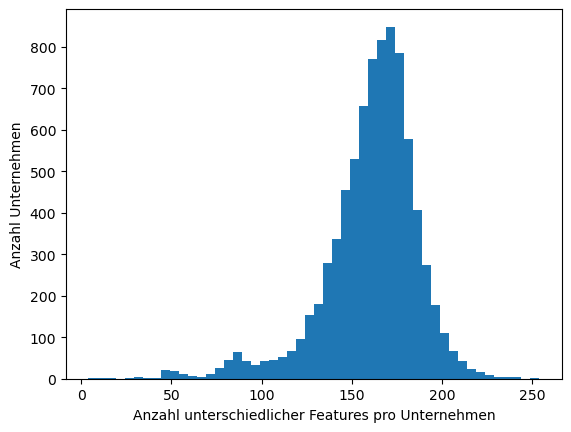

In [3]:
pd.set_option('display.max_rows', 100)
features = fundamentals['ItemName'].unique()
feature_count = len(features)
max_obs_theo = feature_count * 5
max_obs_prax = fundamentals.groupby('EntityCode').size().max()
max_features = fundamentals.groupby('EntityCode')['ItemName'].nunique().max()
min_features = fundamentals.groupby('EntityCode')['ItemName'].nunique().min()
unique_feat = fundamentals.groupby('EntityCode')['ItemName'].nunique()
#Ausgabe
print('Anzahl verschiedener Features insgesamt:', feature_count)
print('Maximale Anzahl verschiedener Features im Datensatz:', max_features)
print('Minimale Anzahl verschiedener Features im Datensatz:', min_features)
print('Anzahl der theoretisch maximalen Observations:', max_obs_theo)
print('Anzahl der tatsächlich maximal beobachteten Observations:',max_obs_prax)
plt.hist(unique_feat, bins=50)
plt.xlabel("Anzahl unterschiedlicher Features pro Unternehmen")
plt.ylabel("Anzahl Unternehmen")
plt.show()

### Bestimmung einer Feature Basis unter dem Aspekt der Lernbarkeit

In [4]:
total_companies = fundamentals['EntityCode'].nunique()
coverage = (
    fundamentals.groupby('ItemName')['EntityCode']
    .nunique()
    .reset_index()
    .rename(columns={'EntityCode': 'company_count'})
    .sort_values('company_count', ascending=False)
)
coverage['coverage_pct'] = coverage['company_count'] / total_companies * 100
#Um ein sinnvolles Lernsignal zu ermöglichen müssen mindestens 50 Beispiele vorhanden sein - Wird auch durch die monatliche Abdeckung nochmals lernbarer, das das Modell die seltenen Features trotzdem öfters sieht.
MIN_COMPANIES = 50
usable_features = coverage[coverage['company_count'] > MIN_COMPANIES]['ItemName'].to_list()
print('Anzahl der Features:', len(usable_features))
print(len(fundamentals))
print(total_companies)
feat_filtered_data = fundamentals[fundamentals['ItemName'].isin(usable_features)].reset_index()

Anzahl der Features: 334
6128609
8120


### Einordnung der NaN-Situation

In [5]:
anz_rows = len(feat_filtered_data)
anz_isna = feat_filtered_data['Value'].isna().sum()
proz_isna = anz_isna / anz_rows
print(f'Anzahl Reihen {anz_rows} - Anzahl NaN {anz_isna} - NaN Prozentual {proz_isna}')
#NaN nach Jahr
nan_per_year = (feat_filtered_data.assign(is_nan=feat_filtered_data["Value"].isna()).groupby(feat_filtered_data["Date"].dt.year)["is_nan"].sum().rename("nan_count"))
total_per_year = (feat_filtered_data.groupby(feat_filtered_data["Date"].dt.year).size().rename("total_count"))
nan_summary = pd.concat([nan_per_year, total_per_year], axis=1)
nan_summary["nan_pct"] = nan_summary["nan_count"] / nan_summary["total_count"] * 100
print(nan_summary)

Anzahl Reihen 6127219 - Anzahl NaN 1270374 - NaN Prozentual 0.2073328862572074
      nan_count  total_count    nan_pct
Date                                   
2021     863290      1037427  83.214530
2022     105397      1262406   8.348899
2023      84479      1287298   6.562505
2024      95137      1285714   7.399546
2025     118861      1218211   9.757013
2026       3210        36163   8.876476


### Feature Harmonisierung. Jede Company bekommt für jedes Jahr einheitliche (usable_features) Features. Nicht vorhandene werden mit NaN aufgefüllt.

In [6]:
items_df = pd.DataFrame({"ItemName": usable_features})
entity_year = feat_filtered_data[["EntityCode", "Date", "EntityID", ]].drop_duplicates().sort_values(["EntityCode", "Date"])
panel = entity_year.merge(items_df, how='cross')
panel_len = len(panel)
data_len = len(feat_filtered_data)
data_nan = feat_filtered_data['Value'].isna().sum()
full_data = panel.merge(feat_filtered_data, how='left', on=['EntityCode', 'Date', 'ItemName'])
print(panel_len)
print(data_len)
print(data_nan)
print(data_len - data_nan)
len(panel) - full_data['Value'].isna().sum()

12933482
6127219
1270374
4856845


4856845

In [7]:
data = full_data[['EntityCode', 'Date', 'ItemName', 'Value']]
wide = data.pivot(index=["EntityCode", "Date"], columns="ItemName", values="Value")
wide = wide.reindex(columns=usable_features)  # feste, garantierte Spaltenreihenfolge
wide = wide.reset_index()
wide

ItemName,EntityCode,Date,TotalEquityGrossMinorityInterest,TotalAssets,TotalLiabilitiesNetMinorityInterest,CommonStockEquity,StockholdersEquity,TaxEffectOfUnusualItems,NetTangibleAssets,TaxRateForCalcs,...,LossAdjustmentExpense,DuefromRelatedPartiesNonCurrent,CashFlowFromDiscontinuedOperation,DuetoRelatedPartiesNonCurrent,UnrealizedGainLoss,TotalPartnershipCapital,PolicyholderBenefitsGross,LimitedPartnershipCapital,InterestReceivedDirect,PolicyholderBenefitsCeded
0,0001.HK,2021-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0001.HK,2022-12-31,8.304796e+10,1.473413e+11,6.429334e+10,6.775044e+10,6.775044e+10,3.253294e+08,1.484181e+10,0.020440,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0001.HK,2023-12-31,8.583796e+10,1.483529e+11,6.251491e+10,7.022722e+10,7.022722e+10,2.010523e+07,1.661653e+10,0.011575,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0001.HK,2024-12-31,8.405899e+10,1.433042e+11,5.924518e+10,6.887550e+10,6.887550e+10,-3.209130e+07,1.600824e+10,0.021267,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0001.HK,2025-12-31,8.847475e+10,1.485315e+11,6.005673e+10,7.232959e+10,7.232959e+10,-3.060221e+08,2.086802e+10,0.034958,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38718,ZYME,2021-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38719,ZYME,2022-12-31,4.929560e+08,6.487250e+08,1.557690e+08,4.929560e+08,4.929560e+08,9.279276e+04,4.545570e+08,0.080549,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38720,ZYME,2023-12-31,4.648060e+08,5.808800e+08,1.160740e+08,4.648060e+08,4.648060e+08,-5.644655e+03,4.275060e+08,0.004763,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38721,ZYME,2024-12-31,3.387680e+08,4.630910e+08,1.243230e+08,3.387680e+08,3.387680e+08,-3.467310e+06,3.221760e+08,0.210000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
feature_mean = wide[usable_features].mean()
feature_std = wide[usable_features].std()
X_scaled = (wide[usable_features] - feature_mean) / feature_std
pd.concat([X_scaled, wide[["EntityCode", "Date"]]], axis=1)

ItemName,TotalEquityGrossMinorityInterest,TotalAssets,TotalLiabilitiesNetMinorityInterest,CommonStockEquity,StockholdersEquity,TaxEffectOfUnusualItems,NetTangibleAssets,TaxRateForCalcs,TangibleBookValue,TotalRevenue,...,CashFlowFromDiscontinuedOperation,DuetoRelatedPartiesNonCurrent,UnrealizedGainLoss,TotalPartnershipCapital,PolicyholderBenefitsGross,LimitedPartnershipCapital,InterestReceivedDirect,PolicyholderBenefitsCeded,EntityCode,Date
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0001.HK,2021-12-31
1,4.425059,0.688868,0.279479,3.784519,3.695607,2.847320,0.812241,-0.916562,0.835150,0.829451,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0001.HK,2022-12-31
2,4.580250,0.694359,0.268990,3.929835,3.837600,0.225228,0.923932,-0.993850,0.949636,0.875055,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0001.HK,2023-12-31
3,4.481297,0.666954,0.249705,3.850528,3.760107,-0.223177,0.885650,-0.909360,0.910396,0.902532,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0001.HK,2024-12-31
4,4.726919,0.695329,0.254491,4.053184,3.958129,-2.576437,1.191498,-0.790004,1.223899,0.895433,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0001.HK,2025-12-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38718,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZYME,2021-12-31
38719,-0.166979,-0.107411,-0.098805,-0.161559,-0.160260,0.053307,-0.093213,-0.392559,-0.092966,-0.119211,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZYME,2022-12-31
38720,-0.168545,-0.107779,-0.099040,-0.163211,-0.161874,0.052461,-0.094916,-1.053232,-0.094711,-0.128806,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZYME,2023-12-31
38721,-0.175556,-0.108419,-0.098991,-0.170605,-0.169099,0.022723,-0.101545,0.735944,-0.101506,-0.128798,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZYME,2024-12-31


In [9]:
train_df = wide[(wide["Date"] <= "2023-12-31") & (wide["Date"] >= "2022-01-01")]
val_df   = wide[(wide["Date"] > "2023-12-31") & (wide["Date"] <= "2024-12-31")]
test_df  = wide[wide["Date"] > "2024-12-31"]

In [10]:
dataset_dict = {
    "X_train": train_df, 
    "X_val": val_df,     
    "X_test": test_df,   
    "usable_features": usable_features
}

joblib.dump(dataset_dict, "../../data/03_gold/fundamentals.pkl")

['../../data/03_gold/fundamentals.pkl']